<a href="https://colab.research.google.com/github/pnhongngoc37-cloud/TH_DeepLearning/blob/main/Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.layers import Conv2D, MaxPooling2D

from sklearn.metrics import f1_score, log_loss
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

CIFAR-10 shapes:
  X_train: (50000, 32, 32, 3)
  X_test : (10000, 32, 32, 3)


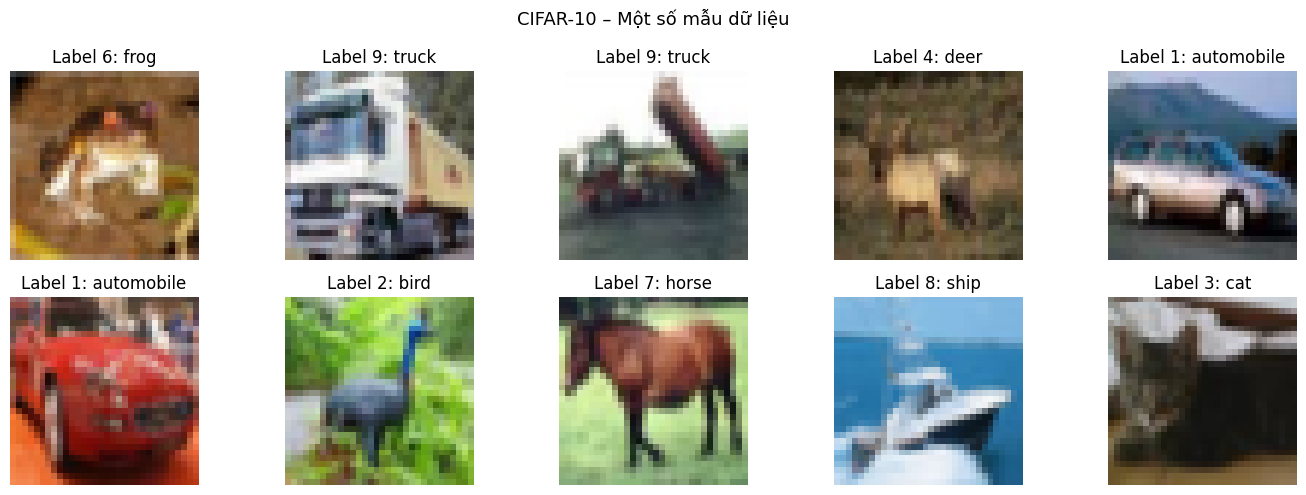

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.2837 - loss: 1.9567 - val_accuracy: 0.3642 - val_loss: 1.7943
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.3468 - loss: 1.8132 - val_accuracy: 0.3722 - val_loss: 1.7491
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.3608 - loss: 1.7725 - val_accuracy: 0.4024 - val_loss: 1.6936
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3789 - loss: 1.7330 - val_accuracy: 0.4134 - val_loss: 1.6491
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3838 - loss: 1.7147 - val_accuracy: 0.4200 - val_loss: 1.6384
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.3925 - loss: 1.6914 - val_accuracy: 0.4254 - val_loss: 1.6280
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.4014 - loss: 1.6656 - val_accuracy: 0.4294 - val_loss: 1.5969
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.4042 - loss: 1.6562 - 

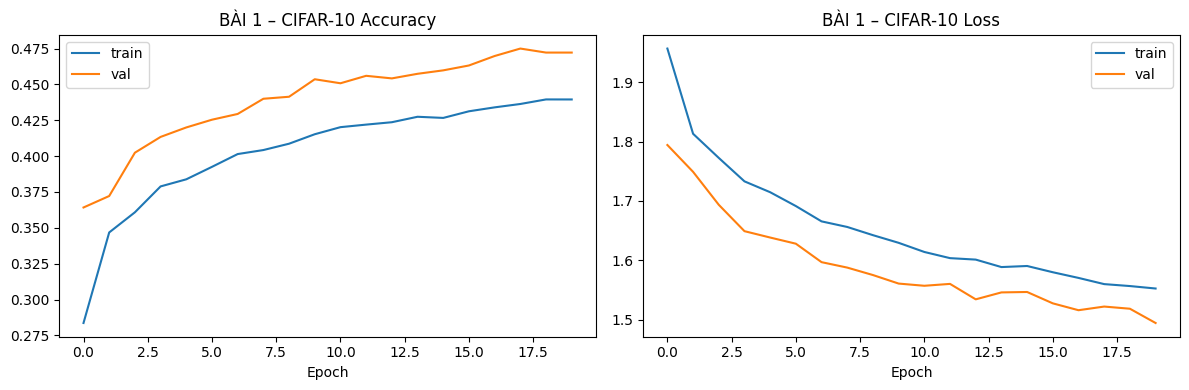

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Dự báo: dog  |  Nhãn thật: cat


In [8]:
# BÀI 1 – NHẬN DẠNG ẢNH VỚI DATASET CIFAR-10
# CIFAR-10 gồm 10 nhãn: airplane, automobile, bird, cat, deer,
#                        dog, frog, horse, ship, truck
# Ảnh màu RGB kích thước 32x32
# -- 1.1  Đọc dữ liệu CIFAR-10 --
(X_train_c, y_train_c), (X_test_c, y_test_c) = tf.keras.datasets.cifar10.load_data()

print("CIFAR-10 shapes:")
print("  X_train:", X_train_c.shape)   # (50000, 32, 32, 3)
print("  X_test :", X_test_c.shape)    # (10000, 32, 32, 3)

class_names_cifar = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

# -- 1.2  Trực quan hóa một vài mẫu --
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_c[i])
    axes[i].set_title(f"Label {y_train_c[i][0]}: {class_names_cifar[y_train_c[i][0]]}")
    axes[i].axis('off')
plt.suptitle("CIFAR-10 – Một số mẫu dữ liệu", fontsize=13)
plt.tight_layout()
plt.show()

# -- 1.3  Tiền xử lý --
# Reshape từ (N,32,32,3) → (N,3072) rồi chuẩn hóa [0,1]
X_train_c_flat = X_train_c.reshape(X_train_c.shape[0], -1).astype('float32') / 255.0
X_test_c_flat  = X_test_c.reshape(X_test_c.shape[0],  -1).astype('float32') / 255.0

y_train_c_flat = y_train_c.flatten()
y_test_c_flat  = y_test_c.flatten()

# -- 1.4  Xây dựng mô hình ANN --
model_cifar = Sequential([
    Dense(512, input_dim=X_train_c_flat.shape[1], activation='relu',
          kernel_initializer='uniform'),
    Dropout(0.3),
    Dense(256, activation='relu', kernel_initializer='uniform'),
    Dropout(0.3),
    Dense(10, activation='softmax', kernel_initializer='uniform')
])

model_cifar.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
model_cifar.summary()

# -- 1.5  Huấn luyện --
history_cifar = model_cifar.fit(
    X_train_c_flat, y_train_c_flat,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

# -- 1.6  Đánh giá --
loss_c, acc_c = model_cifar.evaluate(X_test_c_flat, y_test_c_flat, verbose=0)
print(f"\n[BÀI 1] CIFAR-10 – Test accuracy: {acc_c:.4f}, Test loss: {loss_c:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_cifar.history['accuracy'],    label='train')
plt.plot(history_cifar.history['val_accuracy'],label='val')
plt.title('BÀI 1 – CIFAR-10 Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history_cifar.history['loss'],    label='train')
plt.plot(history_cifar.history['val_loss'],label='val')
plt.title('BÀI 1 – CIFAR-10 Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# -- 1.7  Dự báo ảnh mới --
idx = 0
pred_cifar = np.argmax(model_cifar.predict(X_test_c_flat[[idx]]))
print(f"Dự báo: {class_names_cifar[pred_cifar]}  |  Nhãn thật: {class_names_cifar[y_test_c_flat[idx]]}")

In [ ]:
# ============================================================
# 📌 BÀI 2 – NHẬN DẠNG CHỮ VIẾT SỐ VỚI DATASET MNIST
# ============================================================
# MNIST gồm 10 nhãn: số 0 → 9
# Ảnh xám kích thước 28x28

# from google.colab import files
# uploaded = files.upload()          # upload train.csv, test.csv

# mnist_train = pd.read_csv('mnist_train.csv')
# mnist_test  = pd.read_csv('mnist_test.csv')

# X_train_csv = mnist_train.iloc[:, 1:].values.astype('float32') / 255.0
# y_train_csv = mnist_train.iloc[:, 0].values
# X_test_csv  = mnist_test.iloc[:, 1:].values.astype('float32') / 255.0
# y_test_csv  = mnist_test.iloc[:, 0].values

# Alternative: Load MNIST from Keras datasets directly
(X_train_csv, y_train_csv), (X_test_csv, y_test_csv) = tf.keras.datasets.mnist.load_data()

# Normalize images to [0, 1] and flatten them
X_train_csv = X_train_csv.reshape(X_train_csv.shape[0], -1).astype('float32') / 255.0
X_test_csv  = X_test_csv.reshape(X_test_csv.shape[0],  -1).astype('float32') / 255.0


model_mnist_csv = Sequential([
    Dense(256, input_dim=784, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10,  activation='softmax')
])
model_mnist_csv.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])
model_mnist_csv.fit(X_train_csv, y_train_csv, epochs=30, verbose=1)
loss_csv, acc_csv = model_mnist_csv.evaluate(X_test_csv, y_test_csv)
print(f"[BÀI 2 CSV] Accuracy: {acc_csv:.4f}")

In [7]:
#=============================================================
# 📌 BÀI 3 – NHẬN DẠNG ẢNH CAT vs DOG
# ============================================================
# Nhãn: 0 = Cat, 1 = Dog
# Dữ liệu do giảng viên cung cấp (thư mục train/ chứa ảnh)
# Tên file: cat*.jpg → label 0 | dog*.jpg → label 1
# ------------------------------------------------------------

# -- 3.1  Đọc dữ liệu --
# (Chạy trong Colab: upload thư mục train/ hoặc mount Google Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# folder = '/content/drive/MyDrive/train/'   # <-- sửa đường dẫn

import os
from keras.preprocessing.image import load_img, img_to_array

def load_cat_dog_dataset(folder, img_size=(64, 64)):
    """Đọc ảnh Cat/Dog từ thư mục, trả về (photos, labels)."""
    photos, labels = [], []
    for file in os.listdir(folder):
        label = 0.0 if file.startswith('cat') else 1.0
        img   = load_img(os.path.join(folder, file), target_size=img_size)
        photo = img_to_array(img)
        photos.append(photo)
        labels.append(label)
    photos = np.array(photos, dtype='float32') / 255.0
    labels = np.array(labels)
    np.save('dogs_vs_cats_photos.npy', photos)
    np.save('dogs_vs_cats_labels.npy', labels)
    return photos, labels
# Gọi hàm (bỏ comment khi đã có dữ liệu)
# folder = 'train/'
# photos, labels = load_cat_dog_dataset(folder, img_size=(64, 64))

# Hoặc nạp từ file .npy đã lưu sẵn:
# photos = np.load('dogs_vs_cats_photos.npy')
# labels = np.load('dogs_vs_cats_labels.npy')

# -- 3.2  Tiền xử lý --
# photos_flat = photos.reshape(len(photos), -1)   # (N, 64*64*3)

# -- 3.3  Xây dựng mô hình --
# input_size = photos_flat.shape[1]   # 64*64*3 = 12288
# model_catdog = Sequential([
#     Dense(512, input_dim=input_size, activation='relu'),
#     Dropout(0.4),
#     Dense(256, activation='relu'),
#     Dropout(0.3),
#     Dense(1, activation='sigmoid')      # Binary classification
# ])
# model_catdog.compile(optimizer='adam',
#                      loss='binary_crossentropy',
#                      metrics=['accuracy'])
# model_catdog.summary()

# -- 3.4  Chia train/test & Huấn luyện --
# from sklearn.model_selection import train_test_split
# X_tr, X_te, y_tr, y_te = train_test_split(
#     photos_flat, labels, test_size=0.2, random_state=42)
#
# history_cd = model_catdog.fit(X_tr, y_tr,
#                               validation_data=(X_te, y_te),
#                               epochs=20, batch_size=64, verbose=1)

# -- 3.5  Đánh giá --
# loss_cd, acc_cd = model_catdog.evaluate(X_te, y_te, verbose=0)
# print(f"\n[BÀI 3] Cat vs Dog – Test accuracy: {acc_cd:.4f}")

# -- 3.6  Dự báo ảnh mới --
# def predict_cat_dog(model, img_path, img_size=(64,64)):
#     img = load_img(img_path, target_size=img_size)
#     arr = img_to_array(img).astype('float32') / 255.0
#     arr = arr.reshape(1, -1)
#     prob = model.predict(arr)[0][0]
#     label = 'Dog' if prob >= 0.5 else 'Cat'
#     print(f"Dự báo: {label} (xác suất dog = {prob:.4f})")
#
# predict_cat_dog(model_catdog, 'test_image.jpg')

print("\n[BÀI 3] Uncomment code trên sau khi upload dữ liệu Cat vs Dog.")


[BÀI 3] Uncomment code trên sau khi upload dữ liệu Cat vs Dog.


In [ ]:
# ============================================================
# 📌 BÀI 4 – DỰ BÁO THU NHẬP (ADULT DATASET)
# ============================================================
# Nhãn: <=50K hoặc >50K
# Dữ liệu do giảng viên cung cấp (file adult.csv)
# ------------------------------------------------------------

# -- 4.1  Đọc dữ liệu --
# (Bỏ comment và sửa đường dẫn)
# adult = pd.read_csv('adult.csv')        # hoặc 'adult.data'
# print(adult.head())
# print(adult.shape)
# print(adult.dtypes)

# -- Demo với dữ liệu giả (placeholder) --
# Khi có file thật, thay bằng pd.read_csv(...)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Tạo dữ liệu mẫu 14 features (tương đương adult)
X_adult_demo, y_adult_demo = make_classification(
    n_samples=5000, n_features=14, n_informative=10,
    n_classes=2, random_state=42
)

# === THAY BẰNG CODE THỰC BÊN DƯỚI KHI CÓ DỮ LIỆU ===
# -- 4.2  Tiền xử lý (dùng cho file thật) --
# adult.columns = adult.columns.str.strip()
# adult['income'] = adult['income'].str.strip()
#
# # Mã hóa nhãn
# adult['income'] = (adult['income'] == '>50K').astype(int)
#
# # Mã hóa cột phân loại
# cat_cols = adult.select_dtypes(include='object').columns
# for col in cat_cols:
#     adult[col] = LabelEncoder().fit_transform(adult[col].astype(str))
#
# X = adult.drop('income', axis=1).values.astype('float32')
# y = adult['income'].values
#
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)
# X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(X, y, test_size=0.2, random_state=42)
# =====================================================

# Dùng dữ liệu demo để chạy thử
scaler_a = MinMaxScaler()
X_adult_demo = scaler_a.fit_transform(X_adult_demo).astype('float32')
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(
    X_adult_demo, y_adult_demo, test_size=0.2, random_state=42)

# -- 4.3  Xây dựng mô hình --
model_adult = Sequential([
    Dense(64, input_dim=X_tr_a.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])
model_adult.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])
model_adult.summary()

# -- 4.4  Huấn luyện --
history_adult = model_adult.fit(
    X_tr_a, y_tr_a,
    validation_data=(X_te_a, y_te_a),
    epochs=30, batch_size=64, verbose=1
)

# -- 4.5  Đánh giá --
loss_a, acc_a = model_adult.evaluate(X_te_a, y_te_a, verbose=0)
print(f"\n[BÀI 4] Adult Income – Test accuracy: {acc_a:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_adult.history['accuracy'],    label='train')
plt.plot(history_adult.history['val_accuracy'],label='val')
plt.title('BÀI 4 – Adult Income Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history_adult.history['loss'],    label='train')
plt.plot(history_adult.history['val_loss'],label='val')
plt.title('BÀI 4 – Adult Income Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# -- 4.6  Dự báo --
y_pred_adult = (model_adult.predict(X_te_a) >= 0.5).astype(int).flatten()
print("Vài dự báo đầu tiên:", y_pred_adult[:10])
print("Nhãn thật          :", y_te_a[:10])

In [ ]:
# ============================================================
# 📌 BÀI 5 – ĐÁNH GIÁ CHẤT LƯỢNG XE Ô TÔ (CAR DATASET)
# ============================================================
# Nhãn (cột cuối): unacc, acc, good, vgood
# Dữ liệu do giảng viên cung cấp (file car.csv / car.data)
# ------------------------------------------------------------

# -- 5.1  Đọc dữ liệu --
# car = pd.read_csv('car.csv', header=None)
# print(car.head())
# print(car.shape)

# -- Demo với dữ liệu UCI Car Evaluation (tải trực tiếp) --
CAR_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
car_cols = ['buying','maint','doors','persons','lug_boot','safety','class']

try:
    car = pd.read_csv(CAR_URL, names=car_cols)
    print("\n[BÀI 5] Tải car dataset thành công từ UCI")
    print(car.head())
    print("Phân phối nhãn:\n", car['class'].value_counts())
except Exception:
    print("[BÀI 5] Không tải được từ internet – dùng file giảng viên cung cấp.")
    # car = pd.read_csv('car.csv', header=None, names=car_cols)

# -- 5.2  Tiền xử lý --
car_encoded = car.copy()
le = LabelEncoder()
for col in car_encoded.columns:
    car_encoded[col] = le.fit_transform(car_encoded[col])

X_car = car_encoded.drop('class', axis=1).values.astype('float32')
y_car = car_encoded['class'].values

scaler_car = MinMaxScaler()
X_car = scaler_car.fit_transform(X_car)

n_classes_car = len(np.unique(y_car))
print(f"Số nhãn xe: {n_classes_car}, Classes: {np.unique(y_car)}")

X_tr_car, X_te_car, y_tr_car, y_te_car = train_test_split(
    X_car, y_car, test_size=0.2, random_state=42)

# -- 5.3  Xây dựng mô hình --
model_car = Sequential([
    Dense(64, input_dim=X_tr_car.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(n_classes_car, activation='softmax')
])
model_car.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model_car.summary()

# -- 5.4  Huấn luyện --
history_car = model_car.fit(
    X_tr_car, y_tr_car,
    validation_data=(X_te_car, y_te_car),
    epochs=50, batch_size=32, verbose=1
)

# -- 5.5  Đánh giá --
loss_car, acc_car = model_car.evaluate(X_te_car, y_te_car, verbose=0)
print(f"\n[BÀI 5] Car Quality – Test accuracy: {acc_car:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_car.history['accuracy'],    label='train')
plt.plot(history_car.history['val_accuracy'],label='val')
plt.title('BÀI 5 – Car Quality Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history_car.history['loss'],    label='train')
plt.plot(history_car.history['val_loss'],label='val')
plt.title('BÀI 5 – Car Quality Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# -- 5.6  Dự báo --
y_pred_car = np.argmax(model_car.predict(X_te_car), axis=1)
print("Vài dự báo đầu tiên:", y_pred_car[:10])
print("Nhãn thật          :", y_te_car[:10])